# Task 2: Data Cleaning and Exploratory Data Analysis (EDA) on Titanic Dataset

## 1. Problem Statement

Perform data cleaning and exploratory data analysis (EDA) on the Titanic dataset. Explore the relationships between variables and identify patterns and trends that influence passenger survival.

## 2. Import Required Libraries

In [250]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## 3. Load the Dataset

In [251]:
df = pd.read_csv('titanic-selected-columns.csv')

## 4. Explore the Dataset

In [252]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,class,who,embark_town
0,0,3,male,22.0,1,0,7.2500,Third,man,Southampton
1,1,1,female,38.0,1,0,71.2833,First,woman,Cherbourg
2,1,3,female,26.0,0,0,7.9250,Third,woman,Southampton
3,1,1,female,35.0,1,0,53.1000,First,woman,Southampton
4,0,3,male,35.0,0,0,8.0500,Third,man,Southampton


In [253]:
df.shape

(891, 10)

In [254]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   class        891 non-null    object 
 8   who          891 non-null    object 
 9   embark_town  889 non-null    object 
dtypes: float64(2), int64(4), object(4)
memory usage: 69.7+ KB


In [255]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## 5. Data Cleaning

In [256]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
class            0
who              0
embark_town      2
dtype: int64

In [257]:
df.dropna(subset=['embark_town'],inplace=True)
df['age'] = df['age'].fillna(df['age'].median())

In [258]:
df.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
class          0
who            0
embark_town    0
dtype: int64

In [259]:
print(df.duplicated().sum())
df.drop_duplicates(inplace=True)
print(df.duplicated().sum())

116
0


## 6.Outlier detection & handling

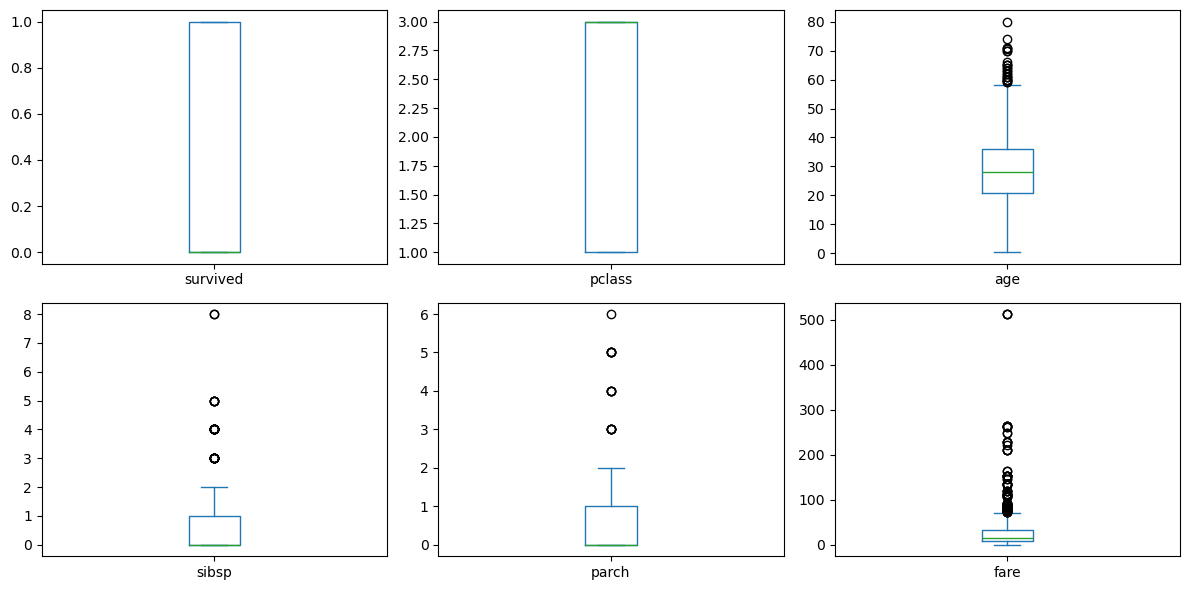

In [260]:
df.select_dtypes(include='number').plot(
    kind='box', 
    figsize=(12, 6), 
    subplots=True, 
    layout=(2, 3)
)
plt.tight_layout()
plt.show()

In [261]:
def find_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers | Range: [{lower:.1f}, {upper:.1f}]")
    return outliers

# Run for each numeric column
for col in ['age', 'fare', 'sibsp', 'parch']:
    find_outliers_iqr(df, col)

age: 26 outliers | Range: [-1.5, 58.5]
fare: 100 outliers | Range: [-30.1, 71.7]
sibsp: 39 outliers | Range: [-1.5, 2.5]
parch: 15 outliers | Range: [-1.5, 2.5]


In [262]:
#Cap outliers (instead of removing, to keep data)
df['fare'] = df['fare'].clip(lower=df['fare'].quantile(0.05), 
                              upper=df['fare'].quantile(0.95))

## 7. Visualization

### Univariant analysis

####  Age Distribution

In [263]:
df['age'].describe()

count    773.000000
mean      29.528357
std       13.731264
min        0.420000
25%       21.000000
50%       28.000000
75%       36.000000
max       80.000000
Name: age, dtype: float64

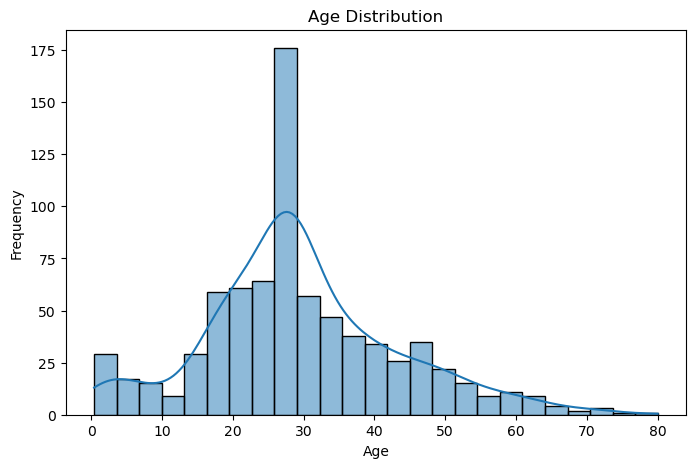

In [264]:
plt.figure(figsize=(8,5))
sns.histplot(data=df,x='age',kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.savefig('Age Distribution.png')
plt.show()

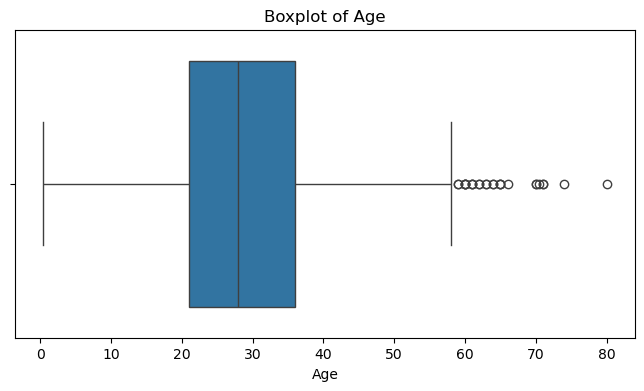

In [265]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['age'])
plt.title('Boxplot of Age')
plt.xlabel('Age')
plt.show()

* Most passengers were between 20 and 40 years old.
* The age distribution is slightly right-skewed.
* Some outliers are present among older passengers.

#### Gender Distribution

In [266]:
df['sex'].value_counts()

sex
male      483
female    290
Name: count, dtype: int64

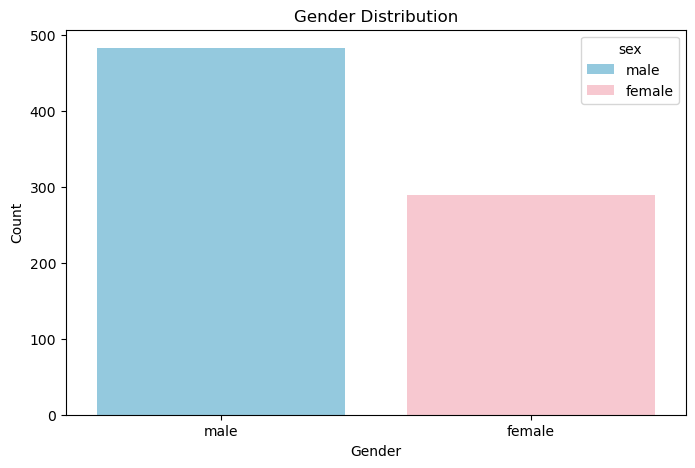

In [267]:
plt.figure(figsize=(8,5))
sns.countplot(data=df,x='sex',palette=['skyblue', 'pink'],hue='sex',legend=True)
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.savefig('Gender Distribution.png')
plt.show()

* Male passengers were more than female passengers.

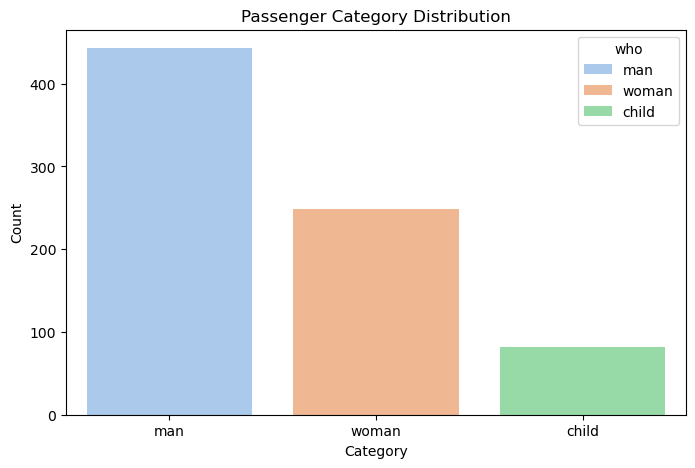

In [268]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='who', palette='pastel', hue='who',legend=True)
plt.title('Passenger Category Distribution')
plt.xlabel('Category')
plt.ylabel('Count')
plt.savefig('Passenger Category Distribution.png')
plt.show()

#### Passenger Class Distribution

In [269]:
df['class'].value_counts()

class
Third     401
First     208
Second    164
Name: count, dtype: int64

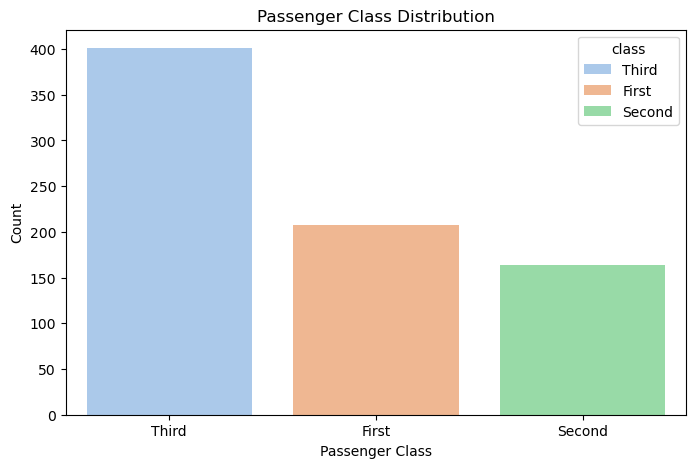

In [270]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='class', palette='pastel', hue='class',legend=True)
plt.title('Passenger Class Distribution')
plt.xlabel('Passenger Class')
plt.ylabel('Count')
plt.savefig('Passenger Class Distribution.png')
plt.show()

* Most passengers traveled in Third Class.
* Second Class had the fewest passengers.

#### Embark Town Distribution

In [271]:
df['embark_town'].value_counts()

embark_town
Southampton    560
Cherbourg      155
Queenstown      58
Name: count, dtype: int64

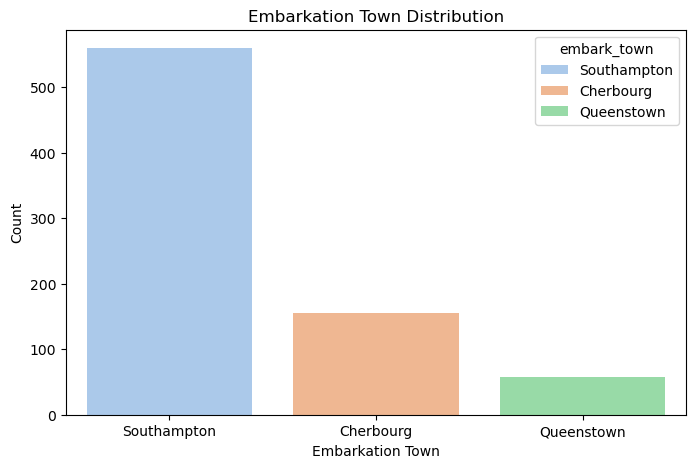

In [272]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='embark_town', palette='pastel', hue='embark_town',legend=True)
plt.title('Embarkation Town Distribution')
plt.xlabel('Embarkation Town')
plt.ylabel('Count')
plt.savefig('Embarkation Town Distribution.png')
plt.show()

* Most passengers boarded from Southampton.

### Bivarient Analysis

#### Sex vs Survival

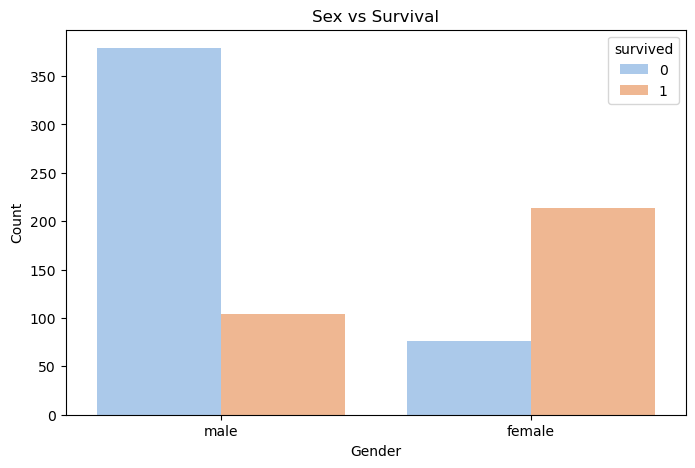

In [273]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='sex', hue='survived', palette='pastel')
plt.title('Sex vs Survival')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.savefig('Sex_vs_Survival.png')
plt.show()

* Females had a significantly higher survival rate than males.

#### Age vs Sex

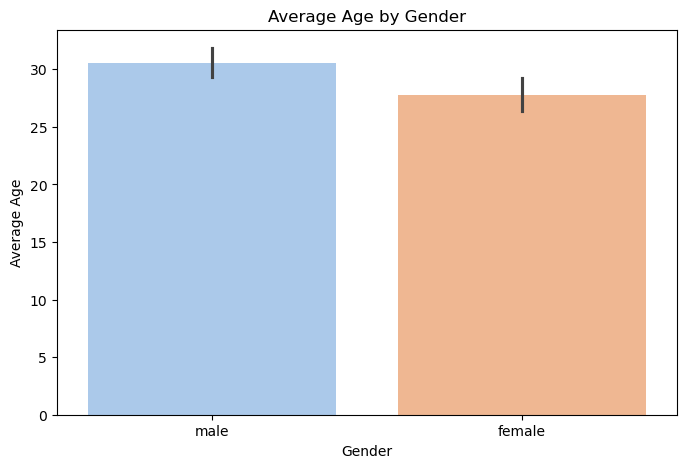

In [274]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='sex', y='age', hue='sex', palette='pastel')
plt.title('Average Age by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Age')
plt.savefig('Average_Age_by_Gender.png')
plt.show()

#### Age vs Survival

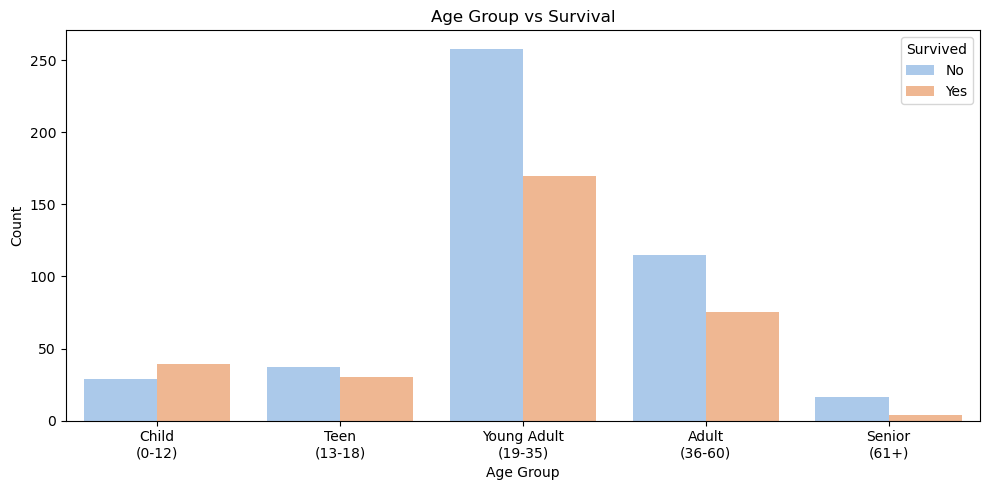

In [275]:
# Create age bins
df['age_group'] = pd.cut(df['age'], 
                          bins=[0, 12, 18, 35, 60, 80],
                          labels=['Child\n(0-12)', 'Teen\n(13-18)', 
                                  'Young Adult\n(19-35)', 'Adult\n(36-60)', 
                                  'Senior\n(61+)'])

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='age_group', hue='survived', palette='pastel')
plt.title('Age Group vs Survival')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.tight_layout()
plt.savefig('AgeGroup_vs_Survival.png')
plt.show()

Children (0–12) had the highest survival rate, reflecting the "women and children first" evacuation policy, while Seniors (61+) had the lowest survival count due to fewer numbers and difficulty during evacuation.

#### Who vs Survival

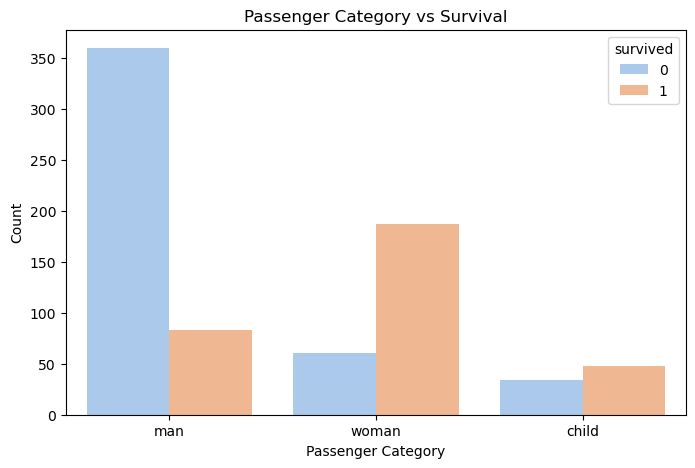

In [276]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='who', hue='survived', palette='pastel')
plt.title('Passenger Category vs Survival')
plt.xlabel('Passenger Category')
plt.ylabel('Count')
plt.savefig('Passenger_Category_vs_Survival.png')
plt.show()

* Women and children had better survival chances than men.

#### Class vs Survival

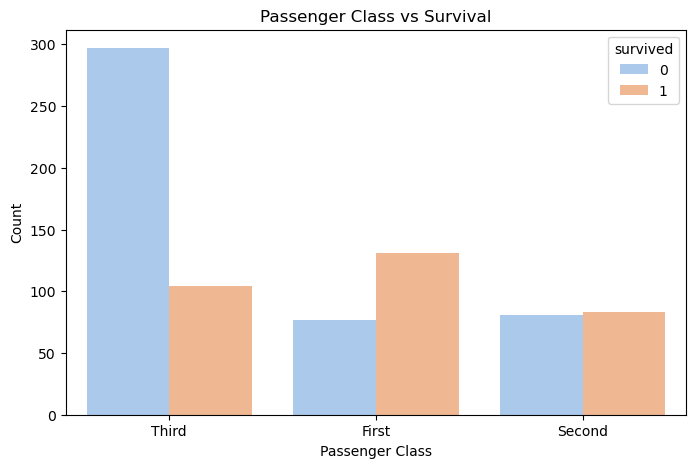

In [277]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='class', hue='survived', palette='pastel')
plt.title('Passenger Class vs Survival')
plt.xlabel('Passenger Class')
plt.ylabel('Count')
plt.savefig('Passenger_Class_vs_Survival.png')
plt.show()

* First Class passengers had the highest survival rate.
* Third Class passengers had the lowest survival rate.

### Multivarient Analysis

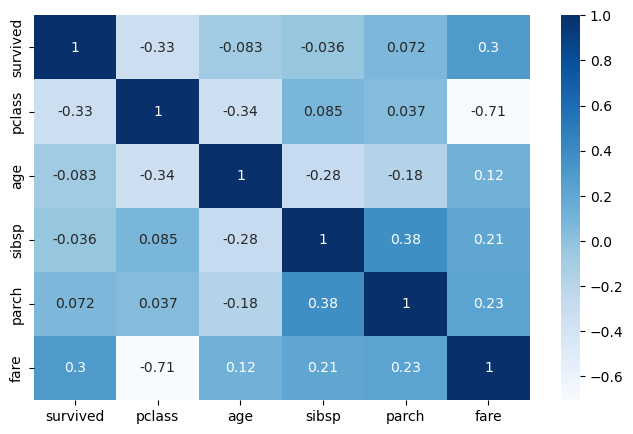

In [278]:
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='Blues')
plt.savefig('Heatmap.png')
plt.show()

Survival shows a strong positive correlation with fare and a moderate positive correlation with being female, indicating that wealthier and female passengers had higher chances of survival.

Passenger class (pclass) has a strong negative correlation with survival, 
confirming that third-class passengers were least likely to survive compared 
to first-class passengers.

## 8. Conclusion :

The exploratory data analysis revealed that passenger survival was strongly influenced by gender, age, and passenger class. Female passengers, children, and First-Class passengers had a higher probability of survival compared to male and Third-Class passengers. Data cleaning improved the quality of the dataset, allowing accurate analysis and visualization of patterns and trends.

## 9. Tools Used
* Python
* Pandas
* Matplotlib
* Seaborn